# SAR Oil Spill Detection — Training Pipeline

**Architecture:** U-Net with pretrained ResNet34 encoder  
**Data:** Sentinel-1 SAR imagery (VV + VH bands) with binary oil spill masks  
**Loss:** Focal Loss + Dice Loss  
**Optimizer:** AdamW with cosine annealing + linear warmup  

---

### Workflow

1. Mount Google Drive & install dependencies
2. Clone source repo from GitHub
3. Preprocess: convert `.tif` images from Drive → `.npz` files on local disk
4. Train the model (reads from fast local storage)
5. Visualize training curves
6. Evaluate on the test set

> **Why local storage?** Reading 50 GB of small `.npz` files from Drive during
> training is bottlenecked by Drive's FUSE mount latency. Copying the
> preprocessed data to `/content/data/` (the Colab VM's local SSD) gives a
> significant speedup during training.

---
## 0 — Configuration

In [ ]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
# Source data on Google Drive (GeoTIFF)
DRIVE_IMAGES_DIR = "/content/drive/MyDrive/Geo_Spill_Data/images"
DRIVE_MASKS_DIR  = "/content/drive/MyDrive/Geo_Spill_Data/masks"

# Local storage for preprocessed .npz files (fast SSD on the Colab VM)
LOCAL_NPZ_DIR    = "/content/npz_cache"
LOCAL_STATS_FILE = "/content/data/train_stats.json"

# Results directory — saved back to Drive so they persist after runtime ends
RESULTS_DIR = "/content/drive/MyDrive/Geo_Spill_results"

# ─── HYPERPARAMETERS ───────────────────────────────────────────────────────────
EPOCHS       = 50
BATCH_SIZE   = 8
PATCH_SIZE   = 256   # random crop size — set to None for full images
LEARNING_RATE = 1e-4
WARMUP_EPOCHS = 5
NUM_WORKERS   = 2    # safe default for Colab

print("Configuration loaded.")

Configuration loaded.


---
## 1 — Mount Google Drive & Install Dependencies

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install -q segmentation-models-pytorch rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00


In [ ]:
# Verify GPU is available
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU detected: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("WARNING: No GPU detected! Go to Runtime → Change runtime type → GPU.")
    print("Training will be extremely slow on CPU.")

GPU detected: Tesla T4 (15.6 GB)


In [ ]:
# Quick sanity check that source data is accessible
import os

for d in [DRIVE_IMAGES_DIR, DRIVE_MASKS_DIR]:
    if os.path.isdir(d):
        n = len([f for f in os.listdir(d) if f.lower().endswith(('.tif', '.tiff'))])
        print(f"  {d} — {n} .tif files found")
    else:
        print(f"  ERROR: {d} not found. Check the path.")

  /content/drive/MyDrive/Geo_Spill_Data/images — 1200 .tif files found
  /content/drive/MyDrive/Geo_Spill_Data/masks — 1200 .tif files found


---
## 2 — Clone Source Repository

Clone the project from GitHub so that `preprocess.py`, `dataset.py`, and
`training.py` are available under `/content/GeoSpill-AI/src/`.

In [ ]:
import os

REPO_URL = "https://github.com/TigranBoyakhchyan/GeoSpill-AI.git"
REPO_DIR = "/content/GeoSpill-AI"
SRC_DIR  = os.path.join(REPO_DIR, "src")

if os.path.isdir(REPO_DIR):
    # Pull latest changes if already cloned (e.g. after a runtime restart)
    !cd {REPO_DIR} && git pull
else:
    !git clone {REPO_URL} {REPO_DIR}

# Verify source files exist
for f in ["preprocess.py", "dataset.py", "training.py"]:
    path = os.path.join(SRC_DIR, f)
    if os.path.isfile(path):
        size = os.path.getsize(path)
        print(f"  {path} — {size:,} bytes")
    else:
        print(f"  ERROR: {path} not found!")

print("\nSource modules ready.")

Cloning into '/content/GeoSpill-AI'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 76 (delta 23), reused 70 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 84.48 KiB | 1.34 MiB/s, done.
Resolving deltas: 100% (23/23), done.
  /content/GeoSpill-AI/src/preprocess.py — 15,860 bytes
  /content/GeoSpill-AI/src/dataset.py — 8,143 bytes
  /content/GeoSpill-AI/src/training.py — 18,006 bytes

Source modules ready.


## 3 — Preprocessing

This step reads `.tif` files from Google Drive, computes per-band normalization
statistics from the training split, and writes compressed `.npz` files to your
Google Drive (`DRIVE_RESULTS`). These files are then copied to the Colab VM's
local disk at `/content/data/npz_cache/` for faster training.

**This is the slowest step** (~30-90 min for 50 GB depending on Drive speed).  
If it gets interrupted, re-run — already-converted files are skipped automatically.

In [ ]:
import sys
sys.path.insert(0, "/content/GeoSpill-AI/src")

import preprocess
DRIVE_RESULTS = "/content/drive/MyDrive/Geo_spill_preprocessed"

stats = preprocess.run(
    images_dir = DRIVE_IMAGES_DIR,
    masks_dir  = DRIVE_MASKS_DIR,
    output_dir = DRIVE_RESULTS,
    stats_file = LOCAL_STATS_FILE,
)

SAR Oil Spill — Preprocessing

Images dir : /content/drive/MyDrive/Geo_Spill_Data/images
Masks dir  : /content/drive/MyDrive/Geo_Spill_Data/masks
Output dir : /content/drive/MyDrive/Geo_spill_preprocessed
Stats file : /content/data/train_stats.json

Scanning dataset...
Found 1200 image-mask pairs
Split      : 840 train | 180 val | 180 test

Computing mean/std from 840 training images...


KeyboardInterrupt: 

Copying from drive into local storage

In [ ]:
import os
import shutil

# Ensure LOCAL_NPZ_DIR exists
os.makedirs(LOCAL_NPZ_DIR, exist_ok=True)

# Define source and destination for images and masks subdirectories
drive_images_src = os.path.join(DRIVE_RESULTS, "images")
drive_masks_src  = os.path.join(DRIVE_RESULTS, "masks")

local_images_dst = os.path.join(LOCAL_NPZ_DIR, "images")
local_masks_dst  = os.path.join(LOCAL_NPZ_DIR, "masks")

print("Starting copy from Drive to local storage...")

# Copy train_stats.json first, as it's often needed early
drive_stats_src = os.path.join(DRIVE_RESULTS, "train_stats.json")
# Ensure the destination directory for LOCAL_STATS_FILE exists
os.makedirs(os.path.dirname(LOCAL_STATS_FILE), exist_ok=True)
if os.path.exists(drive_stats_src):
    print(f"  Copying stats file from {drive_stats_src} to {LOCAL_STATS_FILE}...")
    shutil.copy2(drive_stats_src, LOCAL_STATS_FILE)
    print("  Stats file copied.")
else:
    print(f"  Warning: Source stats file not found: {drive_stats_src}")

# Copy images
if os.path.exists(drive_images_src):
    print(f"  Copying images from {drive_images_src} to {local_images_dst}...")
    if os.path.exists(local_images_dst):
        shutil.rmtree(local_images_dst) # Remove existing local directory to allow copytree
    shutil.copytree(drive_images_src, local_images_dst)
    print("  Images copied.")
else:
    print(f"  Warning: Source image directory not found: {drive_images_src}")

# Copy masks
if os.path.exists(drive_masks_src):
    print(f"  Copying masks from {drive_masks_src} to {local_masks_dst}...")
    if os.path.exists(local_masks_dst):
        shutil.rmtree(local_masks_dst) # Remove existing local directory to allow copytree
    shutil.copytree(drive_masks_src, local_masks_dst)
    print("  Masks copied.")
else:
    print(f"  Warning: Source mask directory not found: {drive_masks_src}")

print("Local storage sync complete.")

Starting copy from Drive to local storage...
  Copying stats file from /content/drive/MyDrive/Geo_spill_preprocessed/train_stats.json to /content/data/train_stats.json...
  Stats file copied.
  Copying images from /content/drive/MyDrive/Geo_spill_preprocessed/images to /content/npz_cache/images...
  Images copied.
  Copying masks from /content/drive/MyDrive/Geo_spill_preprocessed/masks to /content/npz_cache/masks...
  Masks copied.
Local storage sync complete.


Verifying the files

In [ ]:
# Verify preprocessing output
import json

with open(LOCAL_STATS_FILE) as f:
    stats = json.load(f)

print("Normalization statistics:")
print(f"  VV band — mean: {stats['mean'][0]:.4f}, std: {stats['std'][0]:.4f}")
print(f"  VH band — mean: {stats['mean'][1]:.4f}, std: {stats['std'][1]:.4f}")
print(f"  dB clip range: [{stats['db_clip_min']}, {stats['db_clip_max']}]")
print(f"\nSplit sizes:")
print(f"  Train: {stats['n_train']}")
print(f"  Val:   {stats['n_val']}")
print(f"  Test:  {stats['n_test']}")

# Check a few .npz files actually exist
n_img = len([f for f in os.listdir(os.path.join(LOCAL_NPZ_DIR, "images")) if f.endswith(".npz")])
n_msk = len([f for f in os.listdir(os.path.join(LOCAL_NPZ_DIR, "masks"))  if f.endswith(".npz")])
print(f"\nFiles on disk:")
print(f"  {LOCAL_NPZ_DIR}/images/ — {n_img} .npz files")
print(f"  {LOCAL_NPZ_DIR}/masks/  — {n_msk} .npz files")

Normalization statistics:
  VV band — mean: -33.2593, std: 6.1114
  VH band — mean: -19.8870, std: 4.3216
  dB clip range: [-50.0, 0.0]

Split sizes:
  Train: 840
  Val:   180
  Test:  180

Files on disk:
  /content/npz_cache/images/ — 1200 .npz files
  /content/npz_cache/masks/  — 1200 .npz files


changing the paths to `local` in `train_stats.json`

In [ ]:
import json, os

stats_file = LOCAL_STATS_FILE

# What to replace — match your actual setup
DRIVE_PREFIX = "/content/drive/MyDrive/Geo_spill_preprocessed"
LOCAL_PREFIX = LOCAL_NPZ_DIR   # = "/content/npz_cache"

with open(stats_file) as f:
    stats = json.load(f)

def fix(path):
    return path.replace(DRIVE_PREFIX, LOCAL_PREFIX)

stats["splits"]["train"] = [fix(p) for p in stats["splits"]["train"]]
stats["splits"]["val"]   = [fix(p) for p in stats["splits"]["val"]]
stats["splits"]["test"]  = [fix(p) for p in stats["splits"]["test"]]
stats["splits"]["masks"] = {fix(k): fix(v) for k, v in stats["splits"]["masks"].items()}

with open(stats_file, "w") as f:
    json.dump(stats, f, indent=2)

# Verify — all three should show exists: True
print("First 3 training paths after fix:")
for p in stats["splits"]["train"][:3]:
    print(f"  {p}")
    print(f"    exists: {os.path.exists(p)}")

# Also verify a mask path
first_img = stats["splits"]["train"][0]
mask_path = stats["splits"]["masks"][first_img]
print(f"\nFirst mask path: {mask_path}")
print(f"  exists: {os.path.exists(mask_path)}")

First 3 training paths after fix:
  /content/npz_cache/images/01315.npz
    exists: True
  /content/npz_cache/images/00974.npz
    exists: True
  /content/npz_cache/images/00121.npz
    exists: True

First mask path: /content/npz_cache/masks/01315.npz
  exists: True


---
## 4 — Dataset Sanity Check

Quick visual check: load one sample from each split and verify shapes, dtypes,
and value ranges. Also displays an image-mask pair.

In [ ]:
from dataset import build_datasets
import matplotlib.pyplot as plt
import numpy as np

datasets = build_datasets(LOCAL_STATS_FILE, patch_size=PATCH_SIZE)

for split_name, ds in datasets.items():
    print(f"\n{split_name.upper():5s} — {ds}")
    if len(ds) == 0:
        print("  (empty)")
        continue
    img, msk = ds[0]
    print(f"  image : {tuple(img.shape)}, dtype={img.dtype}, "
          f"min={img.min():.3f}, max={img.max():.3f}")
    print(f"  mask  : {tuple(msk.shape)}, dtype={msk.dtype}, "
          f"unique={msk.unique().tolist()}")


TRAIN — SARDataset(n=840, augment=True, patch_size=256)
  image : (2, 256, 256), dtype=torch.float32, min=-2.599, max=2.146
  mask  : (1, 256, 256), dtype=torch.float32, unique=[0.0]

VAL   — SARDataset(n=180, augment=False, patch_size=256)
  image : (2, 256, 256), dtype=torch.float32, min=-2.405, max=2.258
  mask  : (1, 256, 256), dtype=torch.float32, unique=[0.0]

TEST  — SARDataset(n=180, augment=False, patch_size=None)
  image : (2, 2048, 2048), dtype=torch.float32, min=-3.686, max=2.125
  mask  : (1, 2048, 2048), dtype=torch.float32, unique=[0.0, 1.0]


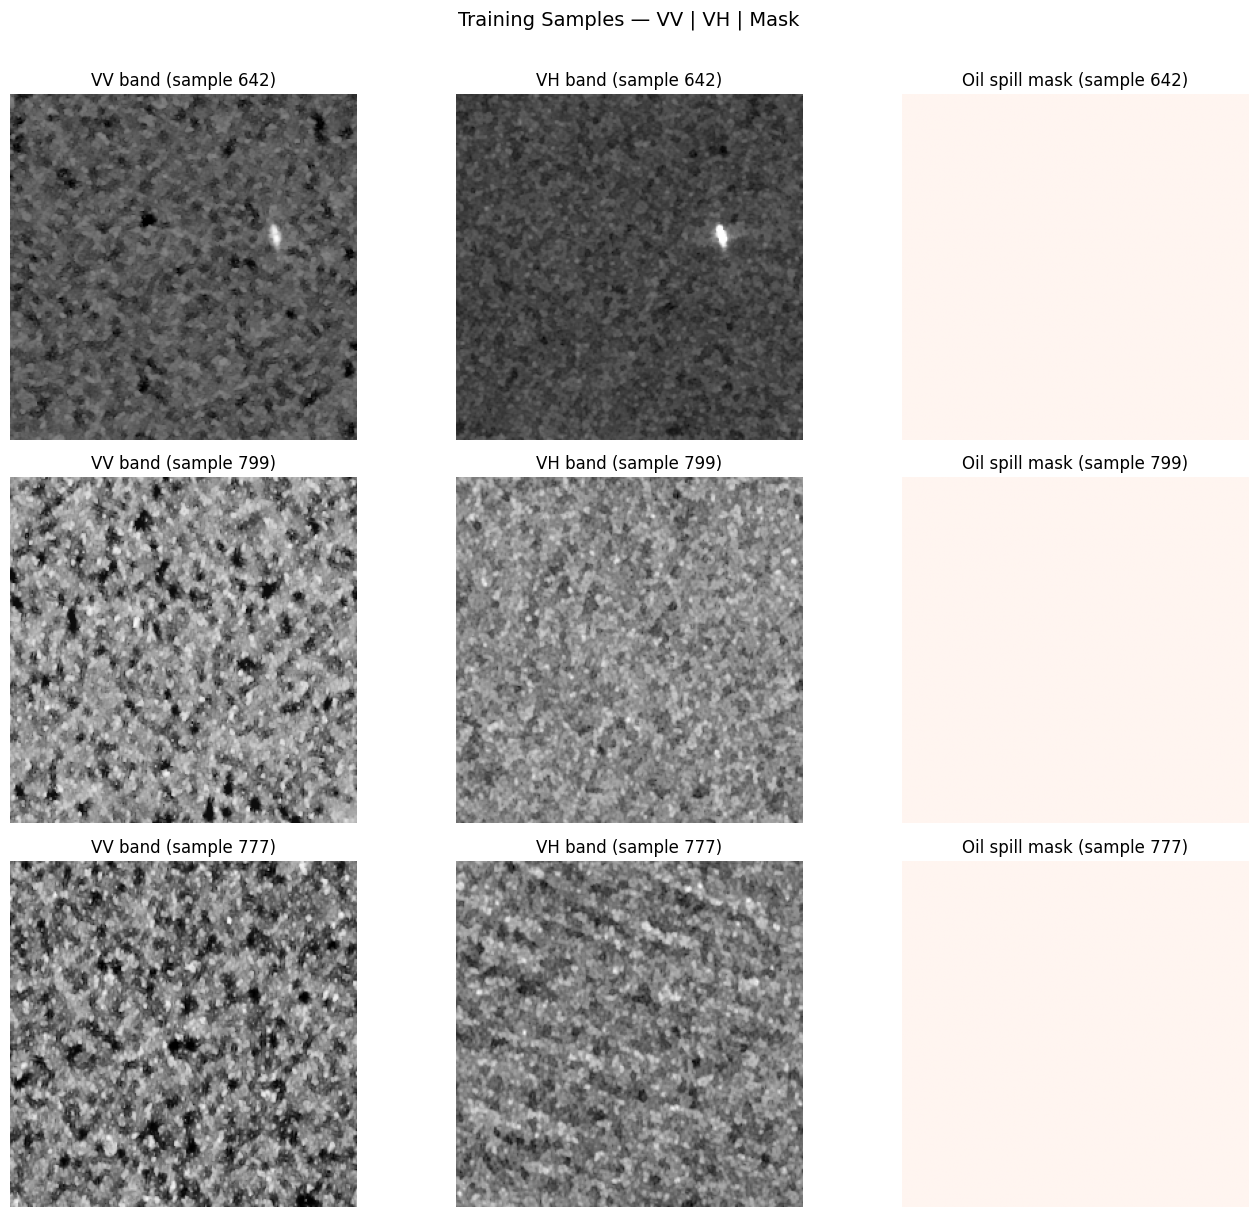

In [ ]:
# Visualize a few training samples
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for row in range(3):
    idx = np.random.randint(0, len(datasets["train"]))
    img, msk = datasets["train"][idx]

    # VV band
    axes[row, 0].imshow(img[0].numpy(), cmap="gray")
    axes[row, 0].set_title(f"VV band (sample {idx})")
    axes[row, 0].axis("off")

    # VH band
    axes[row, 1].imshow(img[1].numpy(), cmap="gray")
    axes[row, 1].set_title(f"VH band (sample {idx})")
    axes[row, 1].axis("off")

    # Mask
    axes[row, 2].imshow(msk[0].numpy(), cmap="Reds", vmin=0, vmax=1)
    axes[row, 2].set_title(f"Oil spill mask (sample {idx})")
    axes[row, 2].axis("off")

plt.suptitle("Training Samples — VV | VH | Mask", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5 — Training

Runs the full training loop. The best checkpoint and CSV log are saved to
Google Drive so they persist after the Colab runtime ends.

The CSV log is flushed every epoch, so if the session is interrupted you
still have partial logs.

In [ ]:
from types import SimpleNamespace

args = SimpleNamespace(
    stats_file    = LOCAL_STATS_FILE,
    output_dir    = RESULTS_DIR,
    epochs        = 50,
    batch_size    = BATCH_SIZE,
    lr            = LEARNING_RATE,
    warmup_epochs = WARMUP_EPOCHS,
    patch_size    = PATCH_SIZE,
    num_workers   = NUM_WORKERS,
    # Point to your existing checkpoint to resume from epoch 7
    resume        = "/content/drive/MyDrive/Geo_Spill_results/best_model_20260416_145208.pt",
)

import training
training.train(args)

Loading datasets...
  Train: 840 samples  Val: 180 samples  Test: 180 samples


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

  SAR Oil Spill Detection — Training
  Device       : cuda
  Architecture : U-Net + ResNet34 (pretrained ImageNet)
  Loss         : Focal + Dice
  Trainable params: 24,433,233
  Epochs       : 50
  Batch size   : 8
  Patch size   : 256
  LR           : 0.0001
  Stats file   : /content/data/train_stats.json
  Output dir   : /content/drive/MyDrive/Geo_Spill_results
[001/50] loss 1.0967 → 1.0394 | IoU 0.1394 | Dice 0.2447 | Prec 0.1412 | Rec 0.9157 | LR 4.00e-05 | 222s
  ✓ New best — IoU 0.1394, Dice 0.2447 → saved to /content/drive/MyDrive/Geo_Spill_results/best_model_20260417_104234.pt
[002/50] loss 1.0067 → 0.9930 | IoU 0.5164 | Dice 0.6811 | Prec 0.5536 | Rec 0.8849 | LR 6.00e-05 | 226s
  ✓ New best — IoU 0.5164, Dice 0.6811 → saved to /content/drive/MyDrive/Geo_Spill_results/best_model_20260417_104234.pt
[003/50] loss 0.9747 → 0.9824 | IoU 0.6098 | Dice 0.7576 | Prec 0.6528 | Rec 0.9024 | LR 8.00e-05 | 231s
  ✓ New best — IoU 0.6098, Dice 0.7576 → saved to /content/drive/MyDrive/Geo_

In [ ]:
import training

training.train(args)

Loading datasets...
  Train: 840 samples  Val: 180 samples  Test: 180 samples
  SAR Oil Spill Detection — Training
  Device       : cuda
  Architecture : U-Net + ResNet34 (pretrained ImageNet)
  Loss         : Focal + Dice
  Trainable params: 24,433,233
  Epochs       : 50
  Batch size   : 8
  Patch size   : 256
  LR           : 0.0001
  Stats file   : /content/data/train_stats.json
  Output dir   : /content/drive/MyDrive/Geo_Spill_results
[001/50] loss 1.4119 → 1.1837 | IoU 0.0332 | Dice 0.0642 | Prec 0.0332 | Rec 0.9792 | LR 4.00e-05 | 234s
  ✓ New best — IoU 0.0332, Dice 0.0642 → saved to /content/drive/MyDrive/Geo_Spill_results/best_model_20260416_145208.pt
[002/50] loss 1.1041 → 1.0465 | IoU 0.2024 | Dice 0.3366 | Prec 0.2076 | Rec 0.8889 | LR 6.00e-05 | 239s
  ✓ New best — IoU 0.2024, Dice 0.3366 → saved to /content/drive/MyDrive/Geo_Spill_results/best_model_20260416_145208.pt
[003/50] loss 1.0264 → 1.0233 | IoU 0.4033 | Dice 0.5747 | Prec 0.4504 | Rec 0.7939 | LR 8.00e-05 | 246s

In [ ]:
import os

# Where train_stats.json currently points
drive_img_dir = "/content/drive/MyDrive/Geo_spill_preprocessed/images"
drive_msk_dir = "/content/drive/MyDrive/Geo_spill_preprocessed/masks"

# Where they should be for fast training
local_img_dir = "/content/npz_cache/images"
local_msk_dir = "/content/npz_cache/masks"

for label, d in [("Drive images", drive_img_dir),
                 ("Drive masks",  drive_msk_dir),
                 ("Local images", local_img_dir),
                 ("Local masks",  local_msk_dir)]:
    if os.path.isdir(d):
        n = len([f for f in os.listdir(d) if f.endswith(".npz")])
        size_gb = sum(os.path.getsize(os.path.join(d, f))
                      for f in os.listdir(d) if f.endswith(".npz")) / 1e9
        print(f"  {label}: {n} files, {size_gb:.2f} GB  [{d}]")
    else:
        print(f"  {label}: not found  [{d}]")

  Drive images: 1200 files, 35.98 GB  [/content/drive/MyDrive/Geo_spill_preprocessed/images]
  Drive masks: 1200 files, 0.01 GB  [/content/drive/MyDrive/Geo_spill_preprocessed/masks]
  Local images: 1200 files, 35.98 GB  [/content/npz_cache/images]
  Local masks: 1200 files, 0.01 GB  [/content/npz_cache/masks]


---
## 6 — Training Curves

Plot loss, IoU, Dice, Precision, and Recall over epochs from the CSV log.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Find the most recent training log
log_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "train_log_*.csv")))
if not log_files:
    print("No training logs found. Run training first.")
else:
    log_path = log_files[-1]
    print(f"Plotting from: {log_path}")
    df = pd.read_csv(log_path)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(df["epoch"], df["train_loss"], label="Train", linewidth=1.5)
    axes[0, 0].plot(df["epoch"], df["val_loss"],   label="Val",   linewidth=1.5)
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # IoU
    axes[0, 1].plot(df["epoch"], df["train_iou"], label="Train", linewidth=1.5)
    axes[0, 1].plot(df["epoch"], df["val_iou"],   label="Val",   linewidth=1.5)
    axes[0, 1].set_title("IoU")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Dice
    axes[1, 0].plot(df["epoch"], df["train_dice"], label="Train", linewidth=1.5)
    axes[1, 0].plot(df["epoch"], df["val_dice"],   label="Val",   linewidth=1.5)
    axes[1, 0].set_title("Dice Score")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Precision & Recall
    axes[1, 1].plot(df["epoch"], df["val_precision"], label="Precision", linewidth=1.5)
    axes[1, 1].plot(df["epoch"], df["val_recall"],    label="Recall",    linewidth=1.5)
    axes[1, 1].set_title("Validation Precision & Recall")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle("Training Progress", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Print best epoch
    best_row = df.loc[df["val_iou"].idxmax()]
    print(f"\nBest epoch: {int(best_row['epoch'])}")
    print(f"  Val IoU:       {best_row['val_iou']:.4f}")
    print(f"  Val Dice:      {best_row['val_dice']:.4f}")
    print(f"  Val Precision: {best_row['val_precision']:.4f}")
    print(f"  Val Recall:    {best_row['val_recall']:.4f}")

---
## 7 — Test Set Evaluation

Load the best checkpoint and evaluate on the held-out test set using
full-resolution images (no patching).

In [ ]:
import segmentation_models_pytorch as smp
from training import compute_metrics

# Find the best checkpoint
ckpt_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "best_model_*.pt")))
if not ckpt_files:
    print("No checkpoint found. Run training first.")
else:
    ckpt_path = ckpt_files[-1]
    print(f"Loading checkpoint: {ckpt_path}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Rebuild model with same architecture
    model = smp.Unet(
        encoder_name    = "resnet34",
        encoder_weights = None,   # weights come from checkpoint
        in_channels     = 2,
        classes         = 1,
    ).to(device)

    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    print(f"  Loaded from epoch {checkpoint['epoch']} "
          f"(val IoU={checkpoint['val_iou']:.4f}, "
          f"val Dice={checkpoint['val_dice']:.4f})")

    # Build test set — full images, no patches
    test_ds = build_datasets(LOCAL_STATS_FILE)["test"]
    test_loader = torch.utils.data.DataLoader(
        test_ds, batch_size=1, shuffle=False, num_workers=2
    )
    print(f"  Test set: {len(test_ds)} samples")

    # Run inference
    all_logits, all_targets = [], []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu())
            all_targets.append(masks)

    all_logits  = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)
    test_metrics = compute_metrics(all_logits, all_targets)

    print("\n" + "=" * 45)
    print("  TEST SET RESULTS")
    print("=" * 45)
    print(f"  IoU       : {test_metrics['iou']:.4f}")
    print(f"  Dice      : {test_metrics['dice']:.4f}")
    print(f"  Precision : {test_metrics['precision']:.4f}")
    print(f"  Recall    : {test_metrics['recall']:.4f}")
    print("=" * 45)

---
## 8 — Visual Predictions

Show a few test images with the model's predictions overlaid on the ground truth.

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
columns = ["VV Band", "Ground Truth", "Prediction"]
for ax, col in zip(axes[0], columns):
    ax.set_title(col, fontsize=13, fontweight="bold")

# Pick 4 random test samples
test_indices = np.random.choice(len(test_ds), size=min(4, len(test_ds)), replace=False)

for row, idx in enumerate(test_indices):
    img, msk = test_ds[idx]

    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        pred   = (torch.sigmoid(logits) > 0.5).float().cpu()

    # VV band
    axes[row, 0].imshow(img[0].numpy(), cmap="gray")
    axes[row, 0].axis("off")

    # Ground truth mask
    axes[row, 1].imshow(img[0].numpy(), cmap="gray")
    axes[row, 1].imshow(msk[0].numpy(), cmap="Reds", alpha=0.4)
    axes[row, 1].axis("off")

    # Prediction mask
    axes[row, 2].imshow(img[0].numpy(), cmap="gray")
    axes[row, 2].imshow(pred[0, 0].numpy(), cmap="Reds", alpha=0.4)
    axes[row, 2].axis("off")

plt.suptitle("Test Predictions — VV | Ground Truth | Model", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 9 — Copy Results to Drive

The checkpoint and CSV log are already saved to Drive during training.
This cell copies the `train_stats.json` there too for completeness.

In [ ]:
import shutil

os.makedirs(RESULTS_DIR, exist_ok=True)

# Copy stats file to results for reference
dst = os.path.join(RESULTS_DIR, "train_stats.json")
shutil.copy2(LOCAL_STATS_FILE, dst)
print(f"Copied stats to: {dst}")

# List everything in results
print(f"\nContents of {RESULTS_DIR}:")
for f in sorted(os.listdir(RESULTS_DIR)):
    size_mb = os.path.getsize(os.path.join(RESULTS_DIR, f)) / 1e6
    print(f"  {f:40s} {size_mb:8.2f} MB")

print("\nAll results saved to Google Drive.")